In [4]:
# Preamble
%load_ext autoreload
# %load_ext memory_profiler
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import maglab.formats.mumax3 as mx3
import maglab.analysis.ringdown as rd
import maglab.loaders.ringdown as l_rd
import maglab.loaders.utils as l_ut
import maglab.processing.state as p_state

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"
table = mx3.read_table(TABLE_PATH)
# table.loc[0, ["mx ()", "my ()", "mz ()"]].to_numpy()
# table.loc[:, table.columns.str.contains("mx|my|mz")]
# table.loc[0, table.columns.str.contains("B_extx|B_exty|B_extz")]
l_ut.compute_dot_vectors(table, ["m", "B_ext"], direction="B_ext")
# table

[array([-1.12721540e-10,  4.52447720e-07,  8.95513100e-07, ...,
        -1.61017460e-08, -1.38172185e-08, -1.07641210e-08], shape=(1201,)),
 array([ 8.3346096e-22,  7.8623110e-08, -2.2975273e-09, ...,
         1.8228659e-10,  4.0687160e-09,  2.3830931e-23], shape=(1201,))]

(0.0, 18.0)

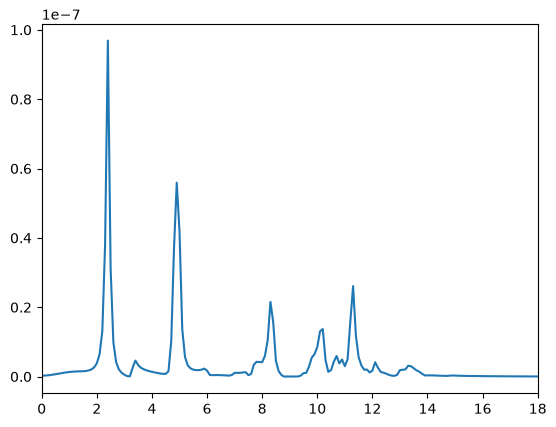

In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"

df = l_rd.load_mag_avg_ringdown(TABLE_PATH)
plt.plot(df["frequency"], df["absorption"])
plt.xlim(0, 18)

In [49]:
dfs = []
for i in [10, 20, 30, 40, 60, 80, 150]:
    dirpath = Path(fr"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_kc{i}.out")
    _, freqs, bls, fmr = l_rd.load_ringdown(dirpath)
    df = pd.DataFrame({"frequency": freqs, f"BLS kc {-i}": bls, f"FMR kc {-i}": fmr})
    dfs.append(df)

Loading OVF files: 100%|██████████| 1201/1201 [00:02<00:00, 569.69 files/s]


Loading OVF files: 100%|██████████| 1201/1201 [00:02<00:00, 586.47 files/s]


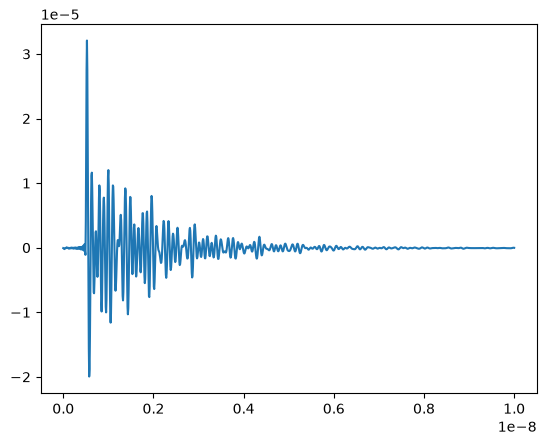

In [34]:
# DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-05-22 AASI Dynamics 2x2\1-1\1-1_phi0_3\1-1_phi0_3exct_B000060.out")
# DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out")
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-21 15nm ASI BLS\E3_256_m100.out")
# (psd, phase), (frequencies, psd_spectrum) = l_rd.load_ringdown(DIRPATH)
# plt.plot(frequencies, psd_spectrum)

spec, freqs, bls, fmr = l_rd.load_ringdown(DIRPATH)

In [ ]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_nomask_damp.out")
absorption, (f, kx, ky) = l_rd.load_dispersion(DIRPATH)

Loading OVF files: 100%|██████████| 1201/1201 [00:00<00:00, 1702.56 files/s]


In [53]:
tot_df = pd.concat(dfs, axis=1)
tot_df = tot_df.loc[:, ~tot_df.columns.duplicated()]
tot_df.to_csv("kc.csv")
# tot_df.loc[:900, :]

Text(0, 0.5, 'BLS intensity (arb. units.)')

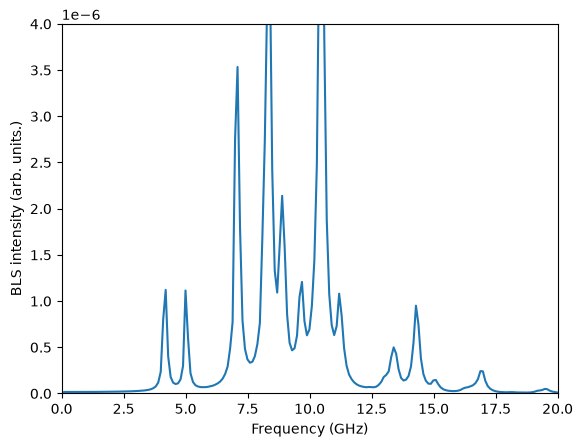

In [3]:
plt.plot(freqs / 1e9, bls)
plt.xlim(0, 20)
# plt.ylim(0, 0.3e-6)
# plt.ylim(0, 0.2e-8)
# plt.ylim(0, 1.2e-6)
# plt.ylim(0, 5e-6)
# plt.ylim(0, 3e-7)
plt.ylim(0, 4e-6)
# plt.ylim(0, 4000e-8)
# plt.ylim(0, 1000e-8)
plt.xlabel("Frequency (GHz)")
plt.ylabel("BLS intensity (arb. units.)")


In [49]:
blss.append(bls)

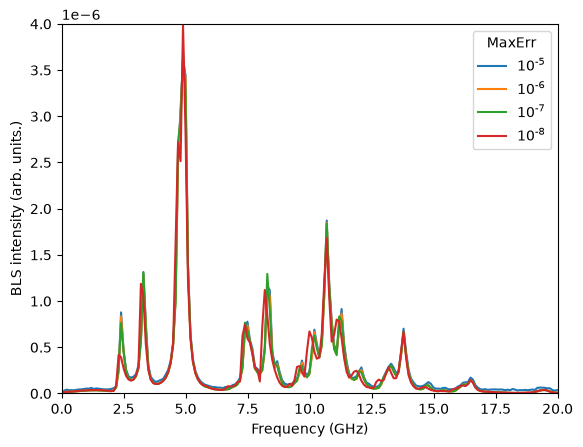

In [51]:
labels = [r"$\text{10}^\text{-5}$", r"$\text{10}^\text{-6}$", r"$\text{10}^\text{-7}$", r"$\text{10}^\text{-8}$"]
for i, b in enumerate(blss):
    plt.plot(freqs / 1e9, b, label = labels[i])
plt.xlim(0, 20)
# plt.ylim(0, 1.2e-6)
plt.ylim(0, 4e-6)
plt.xlabel("Frequency (GHz)")
plt.ylabel("BLS intensity (arb. units.)")
plt.legend(title="MaxErr")

In [ ]:
import pandas as pd
df = pd.DataFrame({"frequency": freqs, -5: blss[0], -6: blss[1], -7: blss[2], -8: blss[3]})


,frequency,-5,-6,-7,-8
0,0.000000e+00,3.744772e-10,4.480344e-10,4.593269e-10,3.409070e-10
1,9.991674e+07,3.040068e-08,1.647327e-08,1.611581e-08,1.606322e-08
2,1.998335e+08,4.126367e-08,1.726781e-08,1.690396e-08,1.703770e-08
3,2.997502e+08,3.640177e-08,1.845320e-08,1.819095e-08,1.826842e-08
4,3.996669e+08,3.656750e-08,2.007266e-08,1.983422e-08,2.008630e-08
...,...,...,...,...,...
596,5.955037e+10,4.011078e-07,4.410792e-09,3.560643e-11,8.882536e-11
597,5.965029e+10,4.271107e-07,6.465083e-09,3.461282e-11,9.034260e-11
598,5.975021e+10,4.311520e-07,4.399629e-09,3.356432e-11,9.632617e-11
599,5.985012e+10,3.459628e-07,3.081498e-09,3.519175e-11,1.017561e-10


In [ ]:
times = [304.0, 300.9, 302.3, 1022.9]
steps = [39729, 39729, 39780, 152939]

In [ ]:
times = [224.9, 198.6, 195.4, 474.7]
steps = [39730, 39727, 39767, 152996]


In [39]:
blss = []

In [ ]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-21 15nm ASI BLS\E3_256_m100.out")


spec, freqs, bls, fmr = l_rd.load_ringdown(DIRPATH)

(601, 6, 256, 256)
(slice(None, None, None), slice(None, None, None), array([171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183,
       184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196,
       197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209,
       210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222,
       223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235,
       236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248,
       249, 250, 251, 252, 253, 254, 255,   0,   1,   2,   3,   4,   5,
         6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,
        19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
        32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
        45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,
        58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,

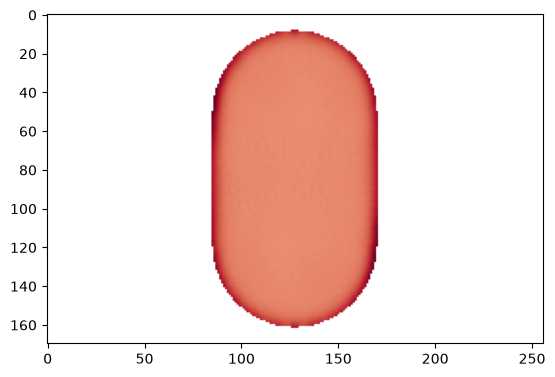

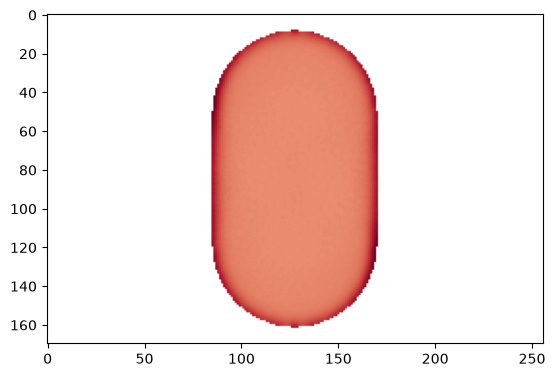

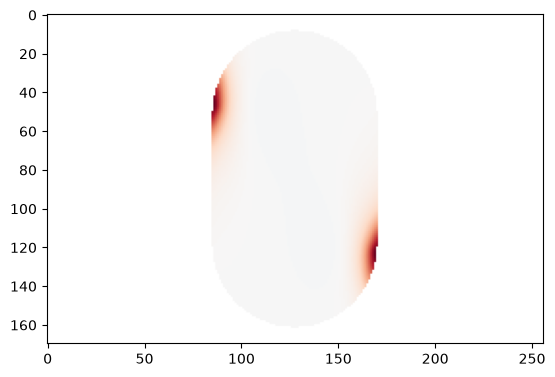

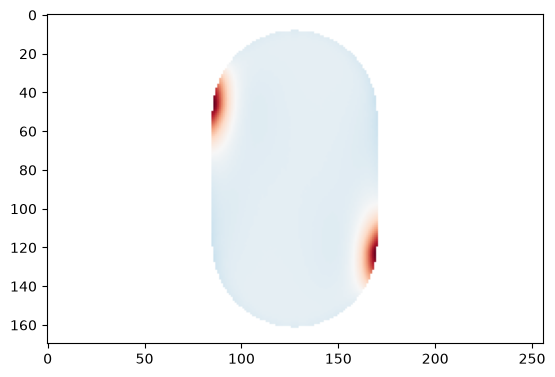

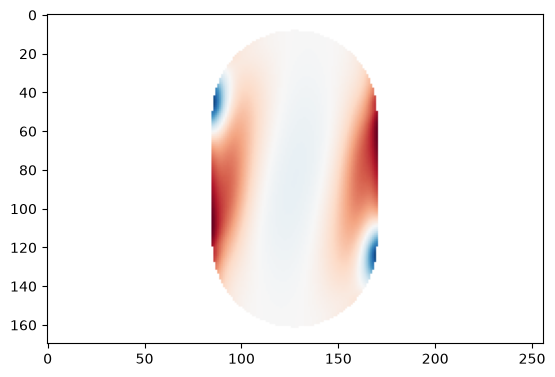

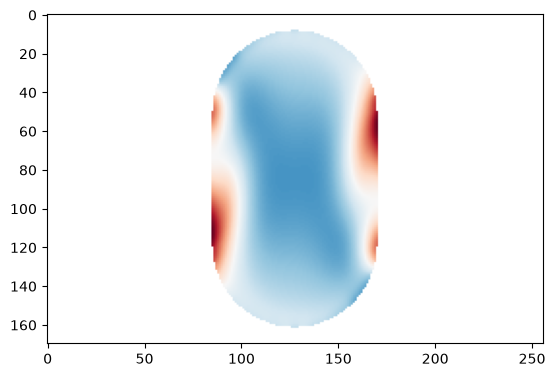

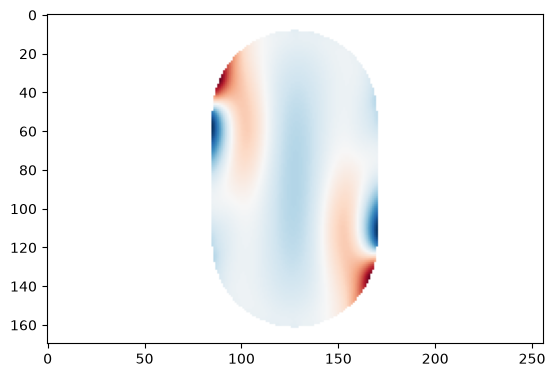

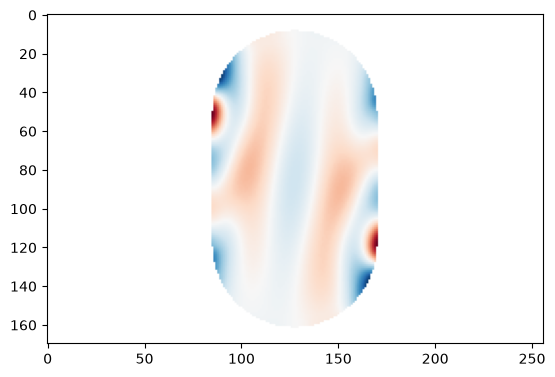

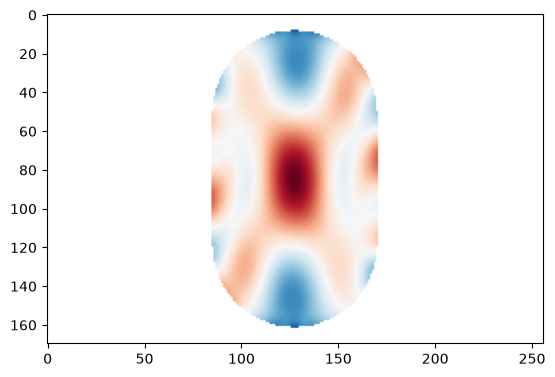

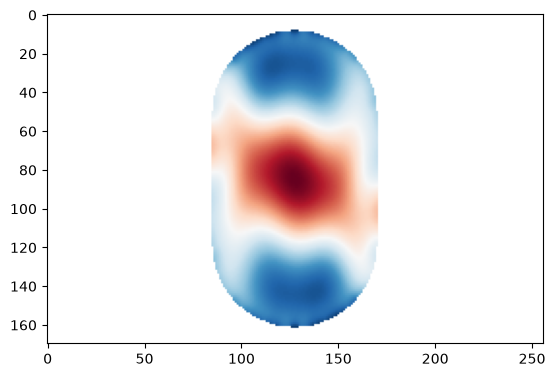

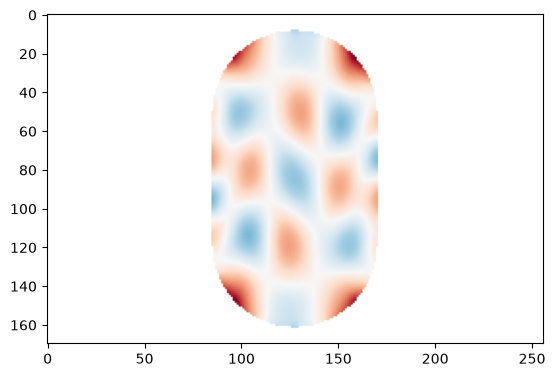

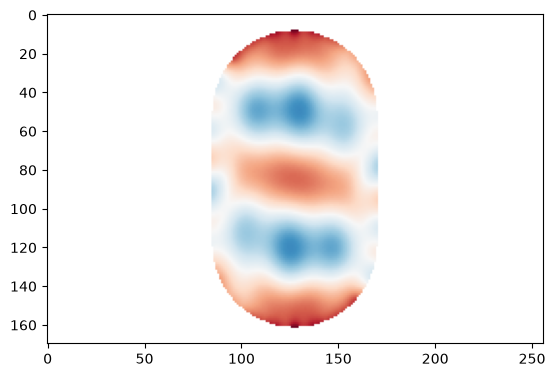

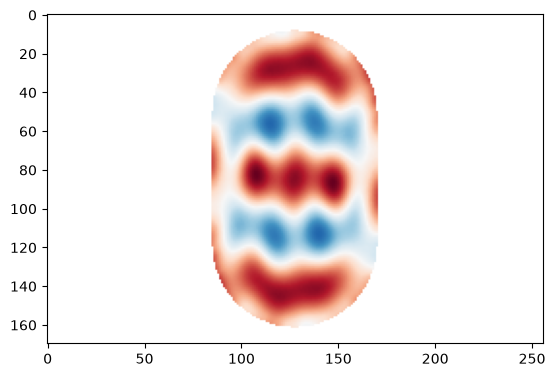

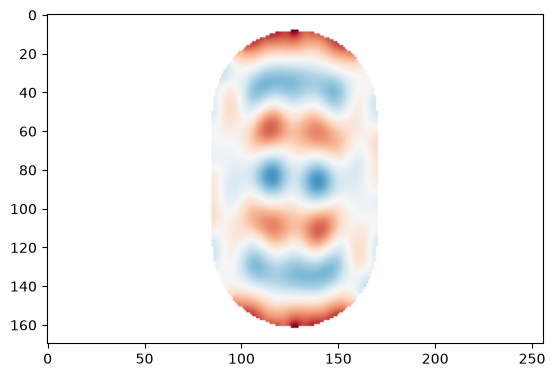

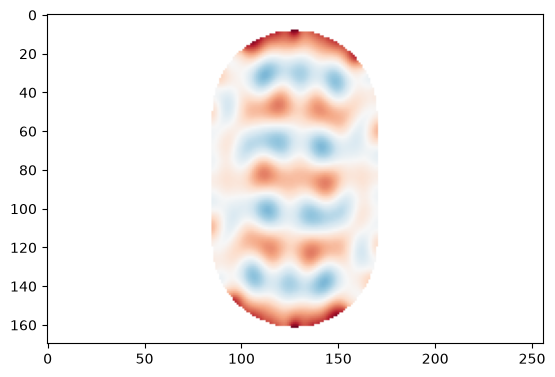

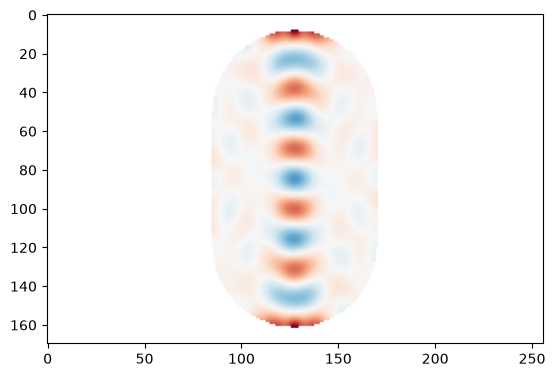

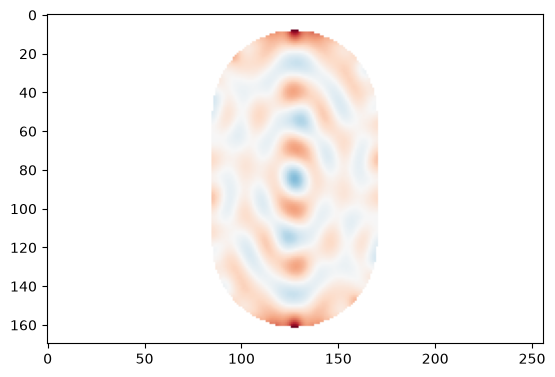

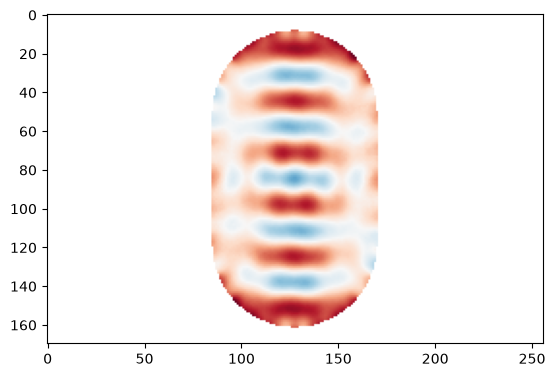

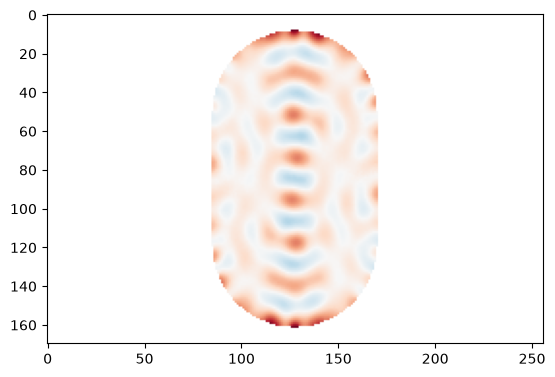

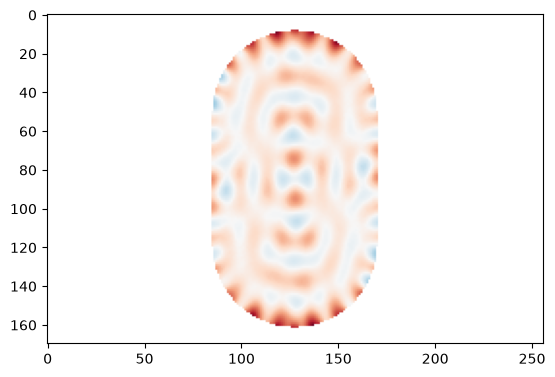

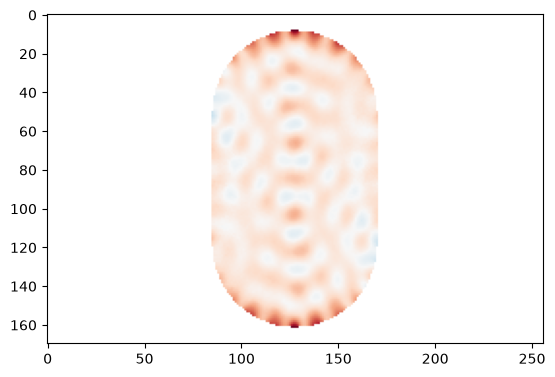

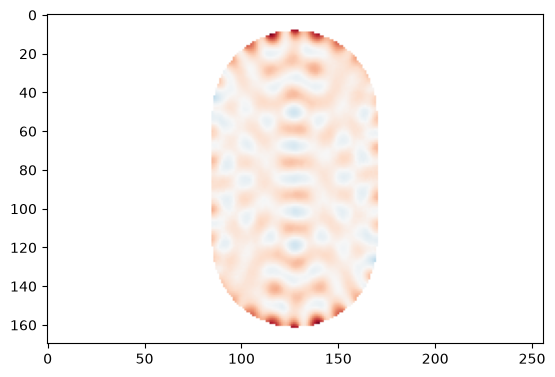

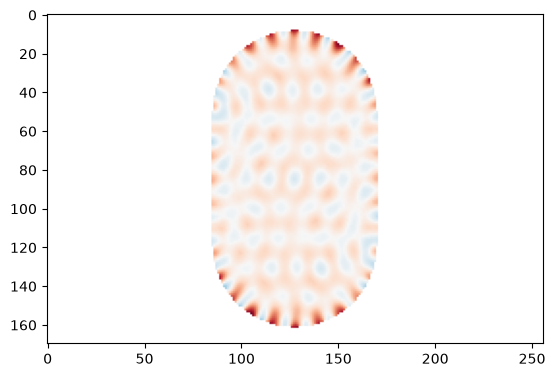

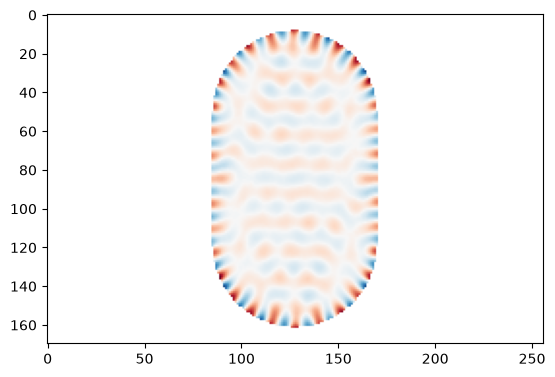

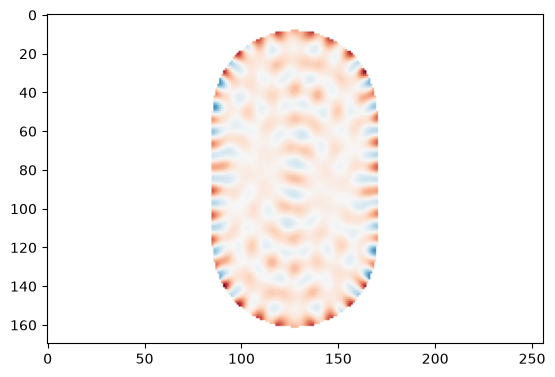

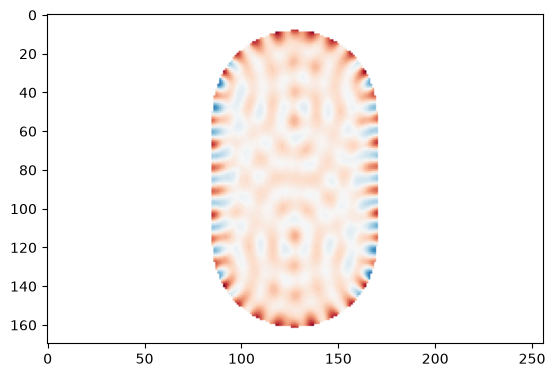

In [31]:
horizontal = (60, 120), (120, 60)
vertical = (60, 120), (120, 60)

a, b = 85, 171

# xrange = (a, b)
# yrange = (b, a)

xrange = (b, a)
yrange = (a, b)


from scipy.signal import find_peaks
peak_idxs, _ = find_peaks(bls[:300])
f_idx = 56
mask = p_state.boundary_slice_mask(spec.shape, [slice(None), slice(None), slice(*xrange), slice(*yrange)])
mask = p_state.boundary_slice_mask(spec.shape, [slice(None), slice(None), slice(*xrange)])
print(spec.shape)
print(mask)
print("ASDFA", p_state.get_mask_shape(spec, mask))
for f_idx in peak_idxs:
    s = spec[mask]
    s = s[f_idx].mean(axis=0)                    # average over z
    s *= np.exp(-1j*np.angle(s.flat[np.argmax(np.abs(s))]))
    v = np.abs(s.real).max()
    s[s == 0.0] = np.nan
    plt.imshow(s.real, cmap='RdBu_r', vmin=-v, vmax=v)
    # plt.imshow(np.log(s.real), cmap="RdBu_r")
    plt.show()

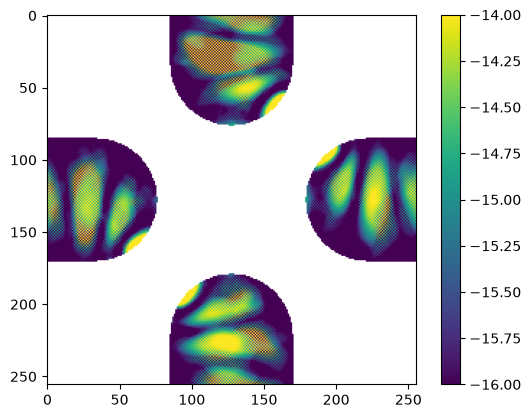

In [40]:
plt.imshow(np.log(psd[46, 4, ...]), clim=(-16, -14))
plt.colorbar()